# Springer Nature API

Von Springer Nature testen wir hier die 2 APIs, Meta API und OA API.


In [29]:
import requests
import getpass
import json

### META API 

In [8]:
SPRINGER_META_KEY = getpass.getpass()

 ········


In [18]:
meta_endpoint = "https://api.springernature.com/meta/v2/json?"

In [19]:
meta_query_params = {
    "api_key": SPRINGER_META_KEY,
    "q": "keyward: test",
    "s": 1,
    "p": 10
    }

In [20]:
meta_resp = requests.get(url=meta_endpoint, params=meta_query_params)
meta_resp.status_code

200

### OA API

Unter OA API gibt es zwei Endpoints:


- /openaccess/json: Retrieve **metadata for open access articles**
- /openaccess/jats: **Access full-text content for open access articles and chapters (where available)**



In [14]:
SPRINGER_OA_KEY = getpass.getpass()

 ········


In [15]:
oa_metadata_endpoint = "https://api.springernature.com/openaccess/json?"

In [16]:
oa_query_params = {
    "api_key": SPRINGER_OA_KEY,
    "q": "keyword: test"
    }

In [17]:
oa_resp = requests.get(url=oa_metadata_endpoint, params=oa_query_params)
oa_resp.status_code

200

## Query erfassen

Springer Nature publiziert die Dokumentation über die Query Parameters hier:
https://dev.springernature.com/docs/supported-query-params/

Demnach können wir noch komplexe "Queries" (Suchabfragen) formulieren. 

In [55]:
oa_query_params2 = {
    "api_key": SPRINGER_OA_KEY,
    "q": "discipline: Arts",
    "p": 5
    }

In [27]:
oa_resp2 = requests.get(url=oa_metadata_endpoint, params=oa_query_params2)
oa_resp2.status_code
oa_res_arts = oa_resp2.json()

In [30]:
print(json.dumps(oa_res_arts, indent=4, sort_keys=True))

{
    "apiMessage": "This JSON was provided by Springer Nature",
    "facets": [
        {
            "name": "subject",
            "values": [
                {
                    "count": "12427",
                    "value": "Education, general"
                },
                {
                    "count": "10939",
                    "value": "Education"
                },
                {
                    "count": "4600",
                    "value": "Social Sciences, general"
                },
                {
                    "count": "3744",
                    "value": "Arts"
                },
                {
                    "count": "3266",
                    "value": "Cultural Studies"
                },
                {
                    "count": "2982",
                    "value": "Social Sciences"
                },
                {
                    "count": "2761",
                    "value": "Materials Science"
                },
       

In [41]:
total_item_num = oa_res_arts["result"][0]["total"]
print(total_item_num)

24622


In [42]:
for facet in oa_res_arts["facets"]:
    if facet["name"] == "subject":
        values = facet["values"]

all_item = 0
subjects_dict = {}
for v in values:
    key = v["value"]
    count = int(v["count"])

    all_item += count
    subjects_dict[key] = count


labels = []
data = []
for key, val in subjects_dict.items():
    val_persent = val / all_item * 100
    subjects_dict[key] = round(val_persent, 2)

    labels.append(key)
    data.append(val_persent)

    
print(subjects_dict)



{'Education, general': 20.7, 'Education': 18.22, 'Social Sciences, general': 7.66, 'Arts': 6.24, 'Cultural Studies': 5.44, 'Social Sciences': 4.97, 'Materials Science': 4.6, 'Materials Science, general': 4.6, 'Linguistics, general': 4.32, 'Law, general': 3.66, 'Literature, general': 3.6, 'Cultural and Media Studies': 2.99, 'Law': 2.21, 'Management': 1.99, 'Media and Communication': 1.98, 'Linguistics': 1.55, 'History, general': 1.44, 'Modern Languages': 1.38, 'Business and Management': 1.26, 'Political Science and International Relations, general': 1.19}


In [44]:
from matplotlib import pyplot 

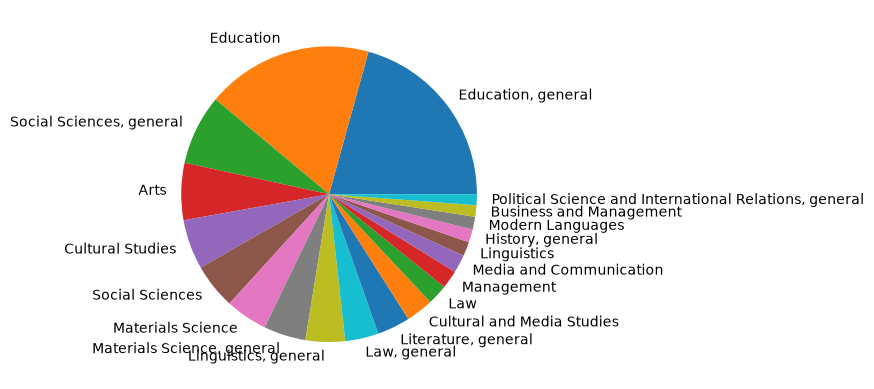

In [46]:
pyplot.pie(data, labels=labels)
pyplot.show()

In [52]:
meta_query_params2 = {
    "api_key": SPRINGER_META_KEY,
    "q": "discipline: Arts AND year: 2026",
    "s": 1,
    "p": 5
    }

In [53]:
meta_resp2 = requests.get(url=meta_endpoint, params=meta_query_params2)
meta_resp2.status_code

200

In [54]:
meta_resp2_json = meta_resp2.json()
print(json.dumps(meta_resp2_json, indent=4, sort_keys=True))

{
    "apiMessage": "This JSON was provided by Springer Nature",
    "facets": [
        {
            "name": "subject",
            "values": [
                {
                    "count": "617",
                    "value": "Education"
                },
                {
                    "count": "559",
                    "value": "Social Sciences, general"
                },
                {
                    "count": "535",
                    "value": "Education, general"
                },
                {
                    "count": "500",
                    "value": "Materials Science"
                },
                {
                    "count": "500",
                    "value": "Materials Science, general"
                },
                {
                    "count": "485",
                    "value": "Social Sciences"
                },
                {
                    "count": "445",
                    "value": "Arts"
                },
      